<a href="https://colab.research.google.com/github/Ancymegona/Data-analysis-using-python/blob/main/Copy_of_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Unnamed: 0  ... Leader
0           0  ...   Modi
1           1  ...   Modi
2           2  ...   Modi
3           3  ...   Modi
4           4  ...   Modi

[5 rows x 4 columns]
                                               Tweet  polarity sentiment
0  @anjanaomkashyap I am seeing you as future #bj...  0.350000  Positive
1  #LokSabhaElections2019 \n23rd May 2019 will re...  0.800000  Positive
2  #LokSabhaElections2019 \n23rd May 2019 will re...  0.800000  Positive
3  PM Modi creates a new record of being the only...  0.312121  Positive
4  @abhijitmajumder Appointment of Successor! \n\...  0.098788  Positive


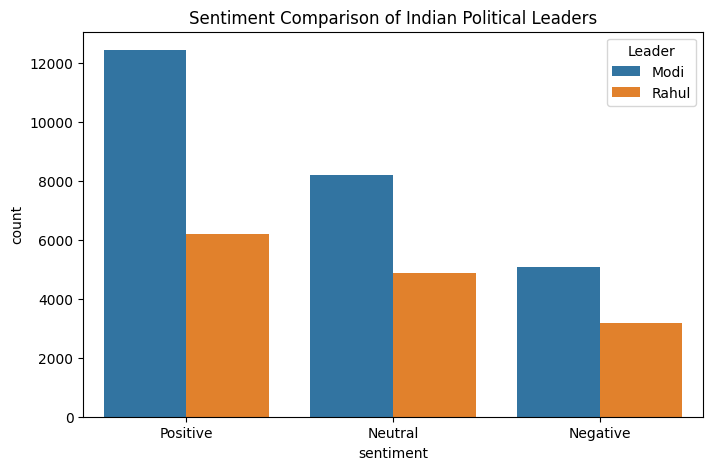

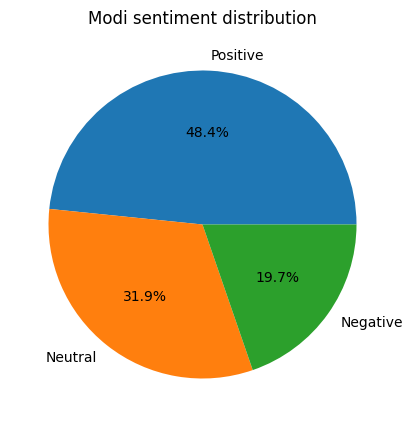

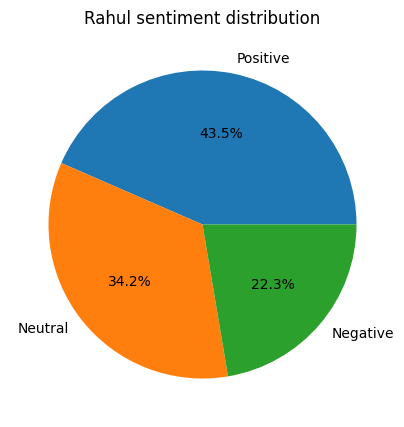

Accuracy score: 0.8748278883464764

classification report:

              precision    recall  f1-score   support

    Negative       0.90      0.68      0.78      1669
     Neutral       0.83      0.96      0.89      2543
    Positive       0.90      0.91      0.90      3777

    accuracy                           0.87      7989
   macro avg       0.88      0.85      0.86      7989
weighted avg       0.88      0.87      0.87      7989



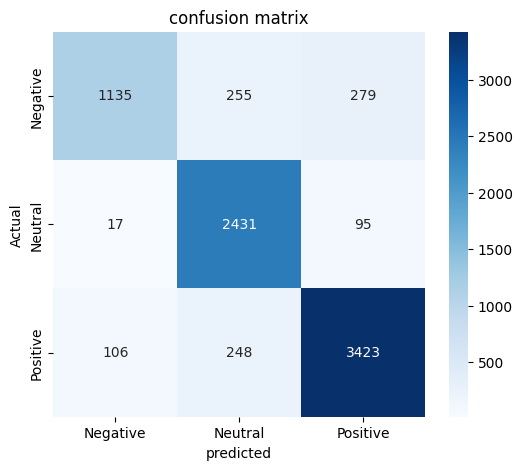


mean polarity by leader:
Leader
Modi     0.108768
Rahul    0.081507
Name: polarity, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Download NLTK data if not already present
# TextBlob relies on 'punkt' tokenizer
try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Corrected exception type to catch LookupError
    nltk.download('punkt')


#load dataset
df1 = pd.read_csv("/content/modi_reviews.csv")
df2 = pd.read_csv("/content/rahul_reviews.csv")
df1.dropna(inplace=True)
df2.dropna(inplace=True)
df1['Leader']="Modi"
df2['Leader']="Rahul"
#combine the 2 datasets
df=pd.concat([df1,df2],ignore_index=True)
print(df.head())

#1- data cleaning
def clean_Text(text):
  text=str(text).lower()
  text=re.sub(r"http\S+","",text)
  text=re.sub(r"@\w+","",text)
  text=re.sub(r"#","",text)
  text=re.sub(r"[^a-zA-Z\s]","",text) # Keep spaces, remove other non-alphabetic
  text=re.sub(r"\s+"," ",text).strip() # Replace multiple spaces with single space and strip
  return text

# Apply the cleaning function
df['clean_tweet']= df['Tweet'].apply(clean_Text) # Changed back to 'Tweet'

#sentiment analysis using TEXTBLOB

def get_polarity(text):
  return TextBlob(text).sentiment.polarity # Corrected method call

# Apply the polarity function
df["polarity"]=df["clean_tweet"].apply(get_polarity)

def get_sentiment(score):
  if score > 0:
    return "Positive"
  elif score < 0:
    return "Negative"
  else:
    return "Neutral"

# Apply the sentiment function
df["sentiment"]=df["polarity"].apply(get_sentiment)
print(df[["Tweet","polarity","sentiment"]].head()) # Changed back to 'Tweet'

# sentiment distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="sentiment",hue="Leader") # Corrected hue column name
plt.title("Sentiment Comparison of Indian Political Leaders")
plt.show()

#visualization
for leader in df["Leader"].unique():
  data = df[df["Leader"]==leader]["sentiment"].value_counts()
  plt.figure(figsize=(5,5))
  data.plot.pie(autopct='%1.1f%%') # Added an extra '%' for proper formatting
  plt.title(f"{leader} sentiment distribution")
  plt.ylabel("")
  plt.show()

#TF-IDF feature extraction(ML MODEL) - Moved outside the loop
vectorizer = TfidfVectorizer(max_features=5000)
x = vectorizer.fit_transform(df['clean_tweet'])
y = df["sentiment"]

#Train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42) # Corrected 'X' to 'x' and 'textsize' to 'test_size'

#Logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

#Accuracy
print("Accuracy score:" , accuracy_score(y_test,y_pred))
print("\nclassification report:\n")
print(classification_report(y_test,y_pred)) # Corrected 'Classification_report' to 'classification_report'

#confusion matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=model.classes_,yticklabels=model.classes_)
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion matrix")
plt.show()

#mean polarity  comparison(business insight)
print("\nmean polarity by leader:")
print(df.groupby("Leader")["polarity"].mean()) # Corrected syntax error